## 1. Load and Preprocess the MNIST Dataset

(60000, 28, 28)
(10000, 28, 28)
Training data shape: (60000, 784)
Test data shape: (10000, 784)


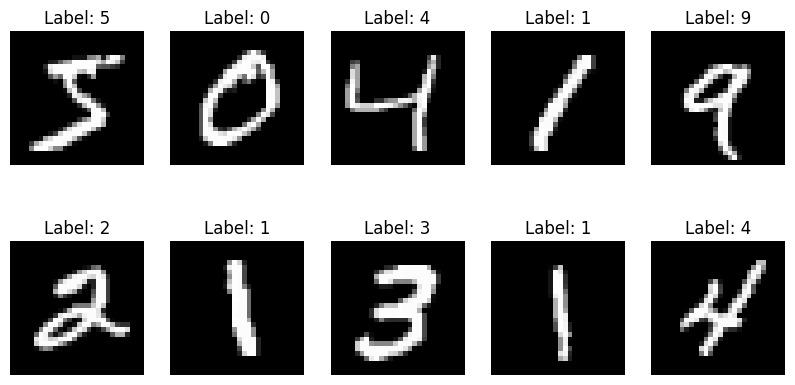

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

#Comment: 
# this section of code will load and shape the dataset into X_train, y_train, X_test, and y_test variables
# we print the shape of X_train so that we can verify the training data's structure for learning.
# the shape will provide us with the number of samples in the set in addition to its dimensionality
# i added this extra line of code so that i may reference the dataset's original shape for X_test
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(X_test.shape) 

#Comment: 
# the following code will normalize the size of X_train and X_test variables for performance. 
# due to the large size of features provided in the dataset, dividing the variables by a number such as
# 225 will make the training and testing variables more efficient for machine learning.
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

#Comment: 
# the data will be reshaped so that they are consistent with the requirements of neural networks.
# neural network requires testing and training data follow a 1D structure.
# prior to reshaping, the following dimesnionalities were provided by the above code:
    ## Training data shape: (60000, 28, 28)
    ## Test data shape: (10000, 28, 28)
# after reshaping, the datasets will be 1D by flattening the 28, 28 vectors into a single 784 vector
X_train = X_train.reshape(X_train.shape[0], 28*28)
X_test = X_test.reshape(X_test.shape[0], 28*28)
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

#Comment: 
# after reshaping the training and testing data, this code will print the first ten images in the X_train set
# this is done by completing a for-loop, which will generate a subplot for every image in range.
# labels are provided with the identity/name of the sample belonging to the corresponding label from the y_train set
# this is done in order to provide us with visual context. in doing so, we can know for certain that the
# data is normalized, that it is greyscale, and what the dataset contains (in this case, handwritten numbers)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


In [6]:
#!pip install tensorflow

## Build the Neural Network Model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Build the neural network model
#Write you code here. Define "model" using Sequential, Input and Dense

# the model will contain a hidden layer of 8 neurons, and an output layer with 10 neurons.
# it will take on the shape of 784 to remain consistent with our flattened datasets
model = Sequential([
    Input(shape=(784,)),  
    Dense(128, activation='relu'),
    #Dense(64, activation='relu'),
    Dense(10, activation='softmax')  
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Neural Network

Epoch 1/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 1.0000 - loss: 1.9266e-11 - val_accuracy: 0.9812 - val_loss: 0.3637
Epoch 2/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 1.8157e-11 - val_accuracy: 0.9812 - val_loss: 0.3642
Epoch 3/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 2.5358e-11 - val_accuracy: 0.9812 - val_loss: 0.3640
Epoch 4/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 2.5612e-11 - val_accuracy: 0.9811 - val_loss: 0.3644
Epoch 5/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 1.9130e-11 - val_accuracy: 0.9812 - val_loss: 0.3645
Epoch 6/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 2.2605e-11 - val_accuracy: 0.9811 - val_loss: 0.3649
Epoch 7/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 2.2425e-11 - val_accuracy: 0.9812 - val_loss: 0.3650
Epoch 8/1000
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1

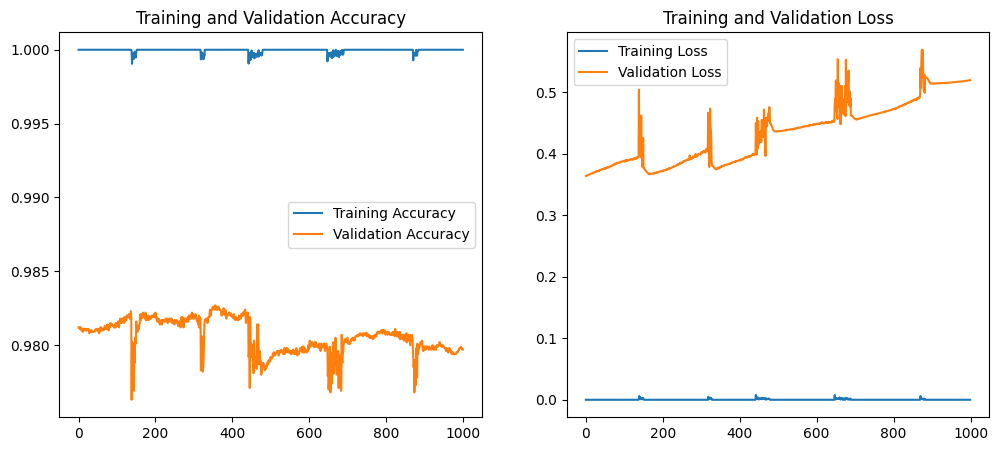

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

#Comment: 
# model.compile will compile the model that was built in the earlier section. Adam is the algorithm that will be used
# to accomplish this task. 
# the loss parameter allows us to recognize a the loss function to be used, in this case it is the sparse categorical crossentropy model.
# this model will calculate the difference between predicted probability dist. of the output vs the true label.
# metrics being set to "accuracy" simply means the compiled model will track for accuracy when providing metric data
model.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Comment: 
# checkpoint will save the most accurate model based on metrics calculated. this will allow the neural network to
# create a checkpoint back to the highest sccoring version of the model being created in order to continue improving itself
# this is done because save_best_only is set to True, with monitor and mode both signalling that the best result will be
# the maximum value of accuracy
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

#Comment: 
# history will hold a fitted version of our model, using traingin data validated against our testing data.
# history will utilize 10 epochs, wherein the model will be checked against validation data at every epoch. callback
# is used in order to hold the most accurate/perfoming model
# when training models, fitting over time allows the programmer to track for performance.
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000, batch_size=32, callbacks=[checkpoint])

#Comment: 
# this section of code will create a subplot demonstrating the model's training accuracy and validation accuracy over time.
# in the context of this project, visualizing performance allows us to monitor to which extent the model is improving
# its accuracy as we iterate over the 10 epochs.
# tracking for accuracy allows us to see whether or not a model is at risk of overfitting (too accurate) or underfitting (not accurate).
# preventing these scenarios ensures the integrity of our predictions.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

#Comment: 
# this section of code will create a subplot demonstrating the model's training loss and validation loss over time.
# in the context of this project, visualizing performance allows us to monitor to which extent the model is improving
# its accuracy as we iterate over the 10 epochs. loss itself will tell us how far the model is from the dataset's true labels.
# underfitting can be identified when loss is consistently high, whilst overfitting can be assumed when the difference between
# validation and training loss is too wide.
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


## Evaluate the Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - accuracy: 0.9791 - loss: 0.4839
Test Accuracy: 0.9827
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.97      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



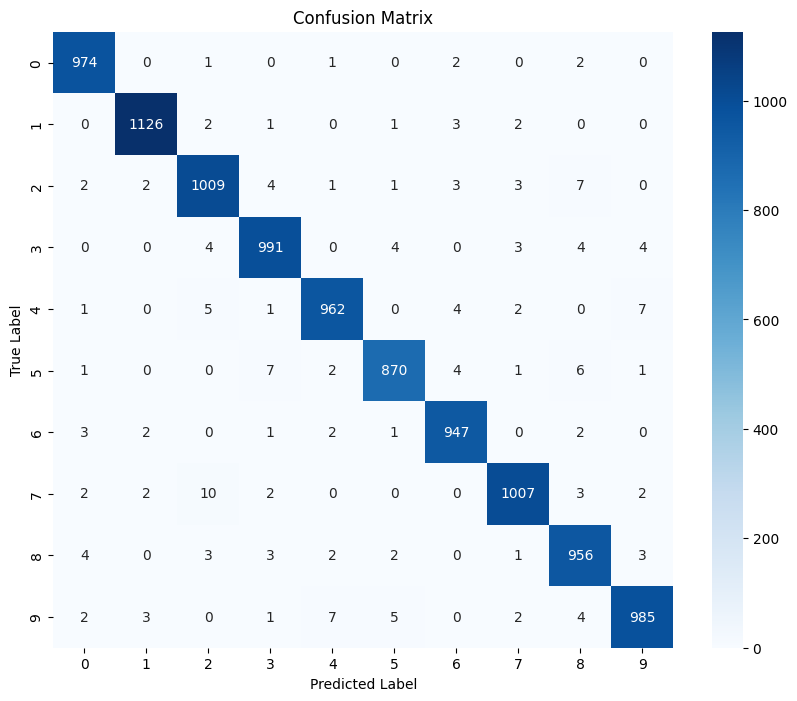

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


best_model = tf.keras.models.load_model('best_model.keras')

#Comment: 
# the variable test_loss will be mapped to the best_model's evaluation on X_test
# the variable test_accuracy will be mapped to y_test's evaluation
# these variables will represent the loss and accuracy found in the model's best performing version. 
# this will provide us with statistics for analysis, which we will print
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

#Comment: 
# this section of code will create another set of variables holding prediction data.
# these variables are then used to generate a report displaying summary statistics for
# prediction data found within the best model.
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

#Comment: 
# a confusion matrix compares the performance of the model's classifications against the test data's 
# own label classifications. 
# the variable cm does this by taking y_test and its corresponding predicted classes, y_pred_classes
cm = confusion_matrix(y_test, y_pred_classes)

#Comment: 
# a visualization of the confusion matrix
# this is done to help provide analysis for the best model's accuracy in predicting labels.
# the confusion matrix is set to color-code labels the model found most difficult in predicting 
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Visualize Predictions

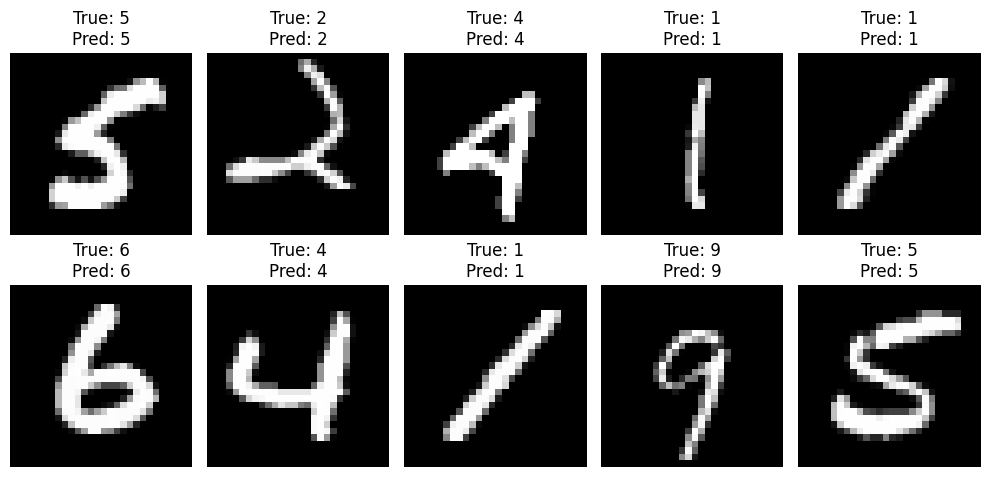

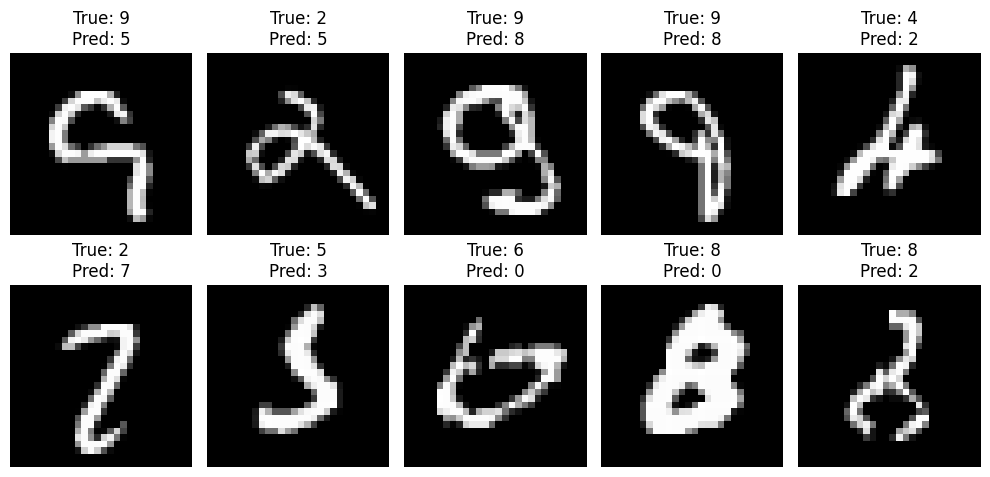

In [29]:
#Comment: 
# 10 random index points from X_test are chosen, these points will be used for visualization purposes
# the indices are random in order to provide a more unbiased view into the model's ability to predict labels
indices = np.random.choice(len(X_test), 10, replace=False)

#Comment: 
# the first visualization will show the random 10 indices we generated and their predicted/true labels
plt.figure(figsize=(10, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

#Comment: 
# an incorrect index is found where the label from y_test is not a match for the corresponding y_pred_classes label at index i
# this is held in the variable incorrect_indicies, which will be used in the next visualiztion
incorrect_indices = np.where(y_test != y_pred_classes)[0]

#Comment: 
# the second visualization will show the incorrect predictions of 10 random indices, and the labels the model confused
plt.figure(figsize=(10, 5))
for i, idx in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
